# Step 4: Training a Deep Q-Network (DQN) Agent

This is the final and most important step. We will train a Deep Q-Network (DQN) agent to master our custom `TaxiDispatchEnvV3` environment.

A DQN uses a neural network to approximate the Q-function, which allows it to handle the enormous state space of our complex environment.

This notebook contains:
1.  **Replay Buffer**: A class to store and sample the agent's experiences.
2.  **DQN Agent**: A class that defines the neural network architecture and the learning algorithm.
3.  **Training Loop**: The main script to run the simulation and train the agent.
4.  **Visualization**: Code to plot the agent's performance.

**Note**: This notebook requires PyTorch. If you don't have it installed, you will need to install it.

In [4]:
# It's recommended to run this in your terminal if you don't have PyTorch
# %pip install torch torchvision torchaudio
# %pip install tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import pandas as pd
import random
from collections import deque, namedtuple
import matplotlib.pyplot as plt
from tqdm import tqdm

import gymnasium as gym
from gymnasium import spaces

# Import our custom environment from the other notebook
# Note: You might need to convert the other notebook to a .py file or run it first
# For simplicity here, I'm including the class definition again.

In [5]:
class TaxiDispatchEnvV3(gym.Env):
    """
    The definitive taxi dispatch environment.

    This version incorporates a pre-computed travel matrix for realistic, time-aware
    cost calculations and uses a profit-maximizing reward function.

    State: A dictionary with 'taxis', 'request', and 'time'.
    - 'taxis': An array of current taxi LocationIDs.
    - 'request': A dictionary with 'origin' and 'destination' LocationIDs.
    - 'time': A dictionary with 'day_of_week' and 'hour_of_day'.

    Action: An integer representing the index of the taxi to dispatch.
    """
    def __init__(self, num_taxis, data_path, matrix_path, cost_per_mile=1.5):
        super(TaxiDispatchEnvV3, self).__init__()

        self.num_taxis = num_taxis
        self.cost_per_mile = cost_per_mile
        
        # Load trip data
        self.df = pd.read_parquet(data_path)
        self.df['tpep_pickup_datetime'] = pd.to_datetime(self.df['tpep_pickup_datetime'])
        self.df['day_of_week'] = self.df['tpep_pickup_datetime'].dt.dayofweek
        self.df['hour_of_day'] = self.df['tpep_pickup_datetime'].dt.hour
        
        # Load and index the travel matrix for fast lookups
        travel_matrix_df = pd.read_parquet(matrix_path)
        self.travel_matrix = travel_matrix_df.set_index(['PULocationID', 'DOLocationID', 'day_of_week', 'hour_of_day'])

        # Get unique locations for defining the space
        self.unique_locations = sorted(pd.concat([self.df['PULocationID'], self.df['DOLocationID']]).unique())
        self.location_map = {loc: i for i, loc in enumerate(self.unique_locations)}
        num_locations = len(self.unique_locations)

        # Define spaces
        self.action_space = spaces.Discrete(num_taxis)
        
        self.observation_space = spaces.Dict({
            'taxis': spaces.MultiDiscrete([num_locations] * num_taxis),
            'request': spaces.Dict({
                'origin': spaces.Discrete(num_locations),
                'destination': spaces.Discrete(num_locations)
            }),
            'time': spaces.Dict({
                'day_of_week': spaces.Discrete(7),
                'hour_of_day': spaces.Discrete(24)
            })
        })

    def _get_observation(self):
        taxi_indices = [self.location_map[loc] for loc in self.taxi_locations]
        origin_index = self.location_map[self.current_trip['PULocationID']]
        dest_index = self.location_map[self.current_trip['DOLocationID']]

        return {
            'taxis': np.array(taxi_indices),
            'request': {'origin': origin_index, 'destination': dest_index},
            'time': {'day_of_week': self.current_trip['day_of_week'], 'hour_of_day': self.current_trip['hour_of_day']}
        }

    def _get_travel_cost(self, origin_id, dest_id, day, hour):
        """Looks up the travel distance from the pre-computed matrix."""
        try:
            # Look up the specific time
            cost = self.travel_matrix.loc[(origin_id, dest_id, day, hour)]
            return cost['mean_distance']
        except KeyError:
            # Fallback: if no data for this specific hour, try to get the average for the day
            try:
                cost = self.travel_matrix.loc[(origin_id, dest_id, day)].mean()
                return cost['mean_distance']
            except KeyError:
                # Fallback: if no data for this route at all, return a high penalty distance
                return 10.0 # High penalty for unknown routes

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.taxi_locations = np.random.choice(self.unique_locations, self.num_taxis)
        self.current_trip = self.df.sample(1, random_state=self.np_random).iloc[0]
        return self._get_observation(), {}

    def step(self, action):
        chosen_taxi_location_id = self.taxi_locations[action]
        
        # Get trip details from the current request
        pickup_location_id = self.current_trip['PULocationID']
        fare = self.current_trip['fare_amount']
        actual_trip_distance = self.current_trip['trip_distance']
        day = self.current_trip['day_of_week']
        hour = self.current_trip['hour_of_day']

        # Calculate deadhead distance using our travel matrix
        deadhead_distance = self._get_travel_cost(chosen_taxi_location_id, pickup_location_id, day, hour)
        
        # Calculate total cost
        total_distance = deadhead_distance + actual_trip_distance
        total_cost = total_distance * self.cost_per_mile
        
        # Calculate profit-based reward
        reward = fare - total_cost
        
        # Update the dispatched taxi's location to the dropoff of the completed trip
        self.taxi_locations[action] = self.current_trip['DOLocationID']
        
        # Get a new trip for the next state
        self.current_trip = self.df.sample(1, random_state=self.np_random).iloc[0]
        
        terminated = True
        
        return self._get_observation(), reward, terminated, False, {}

    def render(self, mode='human'):
        pass

In [6]:
class ReplayBuffer:
    """A simple replay buffer to store and sample experiences."""
    def __init__(self, buffer_size, batch_size, seed):
        self.memory = deque(maxlen=buffer_size)
        self.batch_size = batch_size
        self.experience = namedtuple("Experience", field_names=["state", "action", "reward", "next_state", "done"])
        self.seed = random.seed(seed)

    def add(self, state, action, reward, next_state, done):
        e = self.experience(state, action, reward, next_state, done)
        self.memory.append(e)

    def sample(self):
        experiences = random.sample(self.memory, k=self.batch_size)
        
        # This part is tricky because our state is a dictionary. We need to handle it carefully.
        states = {
            'taxis': torch.from_numpy(np.vstack([e.state['taxis'] for e in experiences if e is not None])).float(),
            'request': {
                'origin': torch.from_numpy(np.vstack([e.state['request']['origin'] for e in experiences if e is not None])).float(),
                'destination': torch.from_numpy(np.vstack([e.state['request']['destination'] for e in experiences if e is not None])).float()
            },
            'time': {
                'day_of_week': torch.from_numpy(np.vstack([e.state['time']['day_of_week'] for e in experiences if e is not None])).float(),
                'hour_of_day': torch.from_numpy(np.vstack([e.state['time']['hour_of_day'] for e in experiences if e is not None])).float()
            }
        }
        actions = torch.from_numpy(np.vstack([e.action for e in experiences if e is not None])).long()
        rewards = torch.from_numpy(np.vstack([e.reward for e in experiences if e is not None])).float()
        
        # We handle next_states similarly
        next_states = {
            'taxis': torch.from_numpy(np.vstack([e.next_state['taxis'] for e in experiences if e is not None])).float(),
            'request': {
                'origin': torch.from_numpy(np.vstack([e.next_state['request']['origin'] for e in experiences if e is not None])).float(),
                'destination': torch.from_numpy(np.vstack([e.next_state['request']['destination'] for e in experiences if e is not None])).float()
            },
            'time': {
                'day_of_week': torch.from_numpy(np.vstack([e.next_state['time']['day_of_week'] for e in experiences if e is not None])).float(),
                'hour_of_day': torch.from_numpy(np.vstack([e.next_state['time']['hour_of_day'] for e in experiences if e is not None])).float()
            }
        }
        dones = torch.from_numpy(np.vstack([e.done for e in experiences if e is not None]).astype(np.uint8)).float()

        return (states, actions, rewards, next_states, dones)

    def __len__(self):
        return len(self.memory)

In [7]:
class DQN(nn.Module):
    """A simple DQN for our complex state."""
    def __init__(self, num_taxis, num_locations):
        super(DQN, self).__init__()
        
        # Embedding layers for categorical features
        self.loc_embedding = nn.Embedding(num_locations, 10)
        self.day_embedding = nn.Embedding(7, 3)
        self.hour_embedding = nn.Embedding(24, 5)
        
        # Combined feature size
        # num_taxis * loc_emb + origin_loc_emb + dest_loc_emb + day_emb + hour_emb
        combined_size = num_taxis * 10 + 10 + 10 + 3 + 5
        
        self.fc1 = nn.Linear(combined_size, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, num_taxis) # Output Q-value for each taxi

    def forward(self, state):
        # Unpack and embed state features
        taxis_locs = self.loc_embedding(state['taxis'].long()).view(state['taxis'].size(0), -1)
        origin_loc = self.loc_embedding(state['request']['origin'].long()).view(state['request']['origin'].size(0), -1)
        dest_loc = self.loc_embedding(state['request']['destination'].long()).view(state['request']['destination'].size(0), -1)
        day = self.day_embedding(state['time']['day_of_week'].long()).view(state['time']['day_of_week'].size(0), -1)
        hour = self.hour_embedding(state['time']['hour_of_day'].long()).view(state['time']['hour_of_day'].size(0), -1)
        
        # Concatenate all features
        x = torch.cat([taxis_locs, origin_loc, dest_loc, day, hour], dim=1)
        
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

In [8]:
class DQNAgent():
    """Interacts with and learns from the environment."""

    def __init__(self, num_taxis, num_locations, seed):
        self.num_taxis = num_taxis
        self.qnetwork_local = DQN(num_taxis, num_locations)
        self.qnetwork_target = DQN(num_taxis, num_locations)
        self.optimizer = optim.Adam(self.qnetwork_local.parameters(), lr=5e-4)

        self.memory = ReplayBuffer(10000, 64, seed)
        self.t_step = 0
    
    def step(self, state, action, reward, next_state, done):
        self.memory.add(state, action, reward, next_state, done)
        
        self.t_step = (self.t_step + 1) % 4
        if self.t_step == 0:
            if len(self.memory) > self.memory.batch_size:
                experiences = self.memory.sample()
                self.learn(experiences, 0.99)

    def act(self, state, eps=0.):
        # Epsilon-greedy action selection
        if random.random() > eps:
            self.qnetwork_local.eval()
            with torch.no_grad():
                # We need to format the state correctly for the network
                s_taxis = torch.from_numpy(state['taxis']).unsqueeze(0).float()
                s_origin = torch.tensor([[state['request']['origin']]]).float()
                s_dest = torch.tensor([[state['request']['destination']]]).float()
                s_day = torch.tensor([[state['time']['day_of_week']]]).float()
                s_hour = torch.tensor([[state['time']['hour_of_day']]]).float()
                
                formatted_state = {
                    'taxis': s_taxis,
                    'request': {'origin': s_origin, 'destination': s_dest},
                    'time': {'day_of_week': s_day, 'hour_of_day': s_hour}
                }
                action_values = self.qnetwork_local(formatted_state)
            self.qnetwork_local.train()
            return np.argmax(action_values.cpu().data.numpy())
        else:
            return random.choice(np.arange(self.num_taxis))

    def learn(self, experiences, gamma):
        states, actions, rewards, next_states, dones = experiences

        # Get max predicted Q values (for next states) from target model
        Q_targets_next = self.qnetwork_target(next_states).detach().max(1)[0].unsqueeze(1)
        # Compute Q targets for current states 
        Q_targets = rewards + (gamma * Q_targets_next * (1 - dones))

        # Get expected Q values from local model
        Q_expected = self.qnetwork_local(states).gather(1, actions)

        # Compute loss
        loss = F.mse_loss(Q_expected, Q_targets)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Update target network
        self.soft_update(self.qnetwork_local, self.qnetwork_target, 1e-3)                     

    def soft_update(self, local_model, target_model, tau):
        for target_param, local_param in zip(target_model.parameters(), local_model.parameters()):
            target_param.data.copy_(tau*local_param.data + (1.0-tau)*target_param.data)

In [9]:
# --- Hyperparameters ---
NUM_TAXIS = 5
DATA_PATH = 'data/yellow_tripdata_2025-01_manhattan.parquet'
MATRIX_PATH = 'data/travel_matrix.parquet'

# --- Instantiate Environment and Agent ---
env = TaxiDispatchEnvV3(num_taxis=NUM_TAXIS, data_path=DATA_PATH, matrix_path=MATRIX_PATH)
agent = DQNAgent(num_taxis=NUM_TAXIS, num_locations=len(env.unique_locations), seed=0)

# --- Training ---
n_episodes = 2000
max_t = 1 # Since each episode is one decision
eps_start = 1.0
eps_end = 0.01
eps_decay = 0.995

scores = []
scores_window = deque(maxlen=100)
eps = eps_start

for i_episode in tqdm(range(1, n_episodes+1)):
    state, _ = env.reset()
    score = 0
    for t in range(max_t):
        action = agent.act(state, eps)
        next_state, reward, done, _, _ = env.step(action)
        agent.step(state, action, reward, next_state, done)
        state = next_state
        score += reward
        if done:
            break 
    scores_window.append(score)
    scores.append(score)
    eps = max(eps_end, eps_decay*eps)
    
    if i_episode % 100 == 0:
        print(f'\rEpisode {i_episode}\tAverage Score: {np.mean(scores_window):.2f}')

print('Training complete.')

 13%|█▎        | 256/2000 [00:00<00:02, 857.25it/s]

Episode 100	Average Score: 4.20
Episode 200	Average Score: 3.20


 22%|██▏       | 441/2000 [00:00<00:01, 898.90it/s]

Episode 300	Average Score: 3.48
Episode 400	Average Score: 3.20


 31%|███▏      | 626/2000 [00:00<00:01, 912.93it/s]

...

Episode 1300	Average Score: 4.16
Episode 1400	Average Score: 4.54


 84%|████████▍ | 1680/2000 [00:01<00:00, 982.89it/s]

Episode 1500	Average Score: 4.93
Episode 1600	Average Score: 3.25
Episode 1700	Average Score: 3.71


100%|██████████| 2000/2000 [00:02<00:00, 929.54it/s]

Episode 1800	Average Score: 4.65
Episode 1900	Average Score: 4.63
Episode 2000	Average Score: 3.84
Training complete.


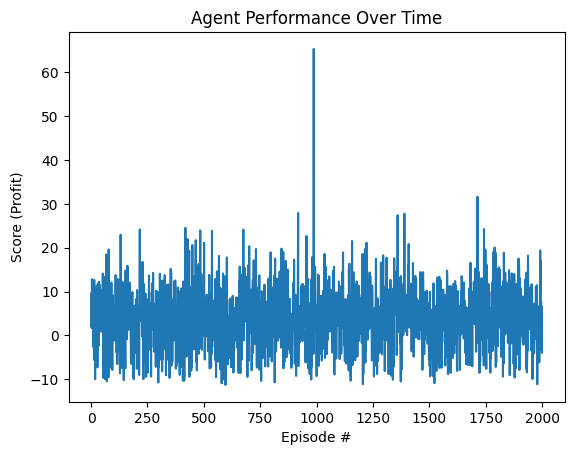

In [10]:
# Plot the scores
fig = plt.figure()
ax = fig.add_subplot(111)
plt.plot(np.arange(len(scores)), scores)
plt.ylabel('Score (Profit)')
plt.xlabel('Episode #')
plt.title('Agent Performance Over Time')
plt.show()